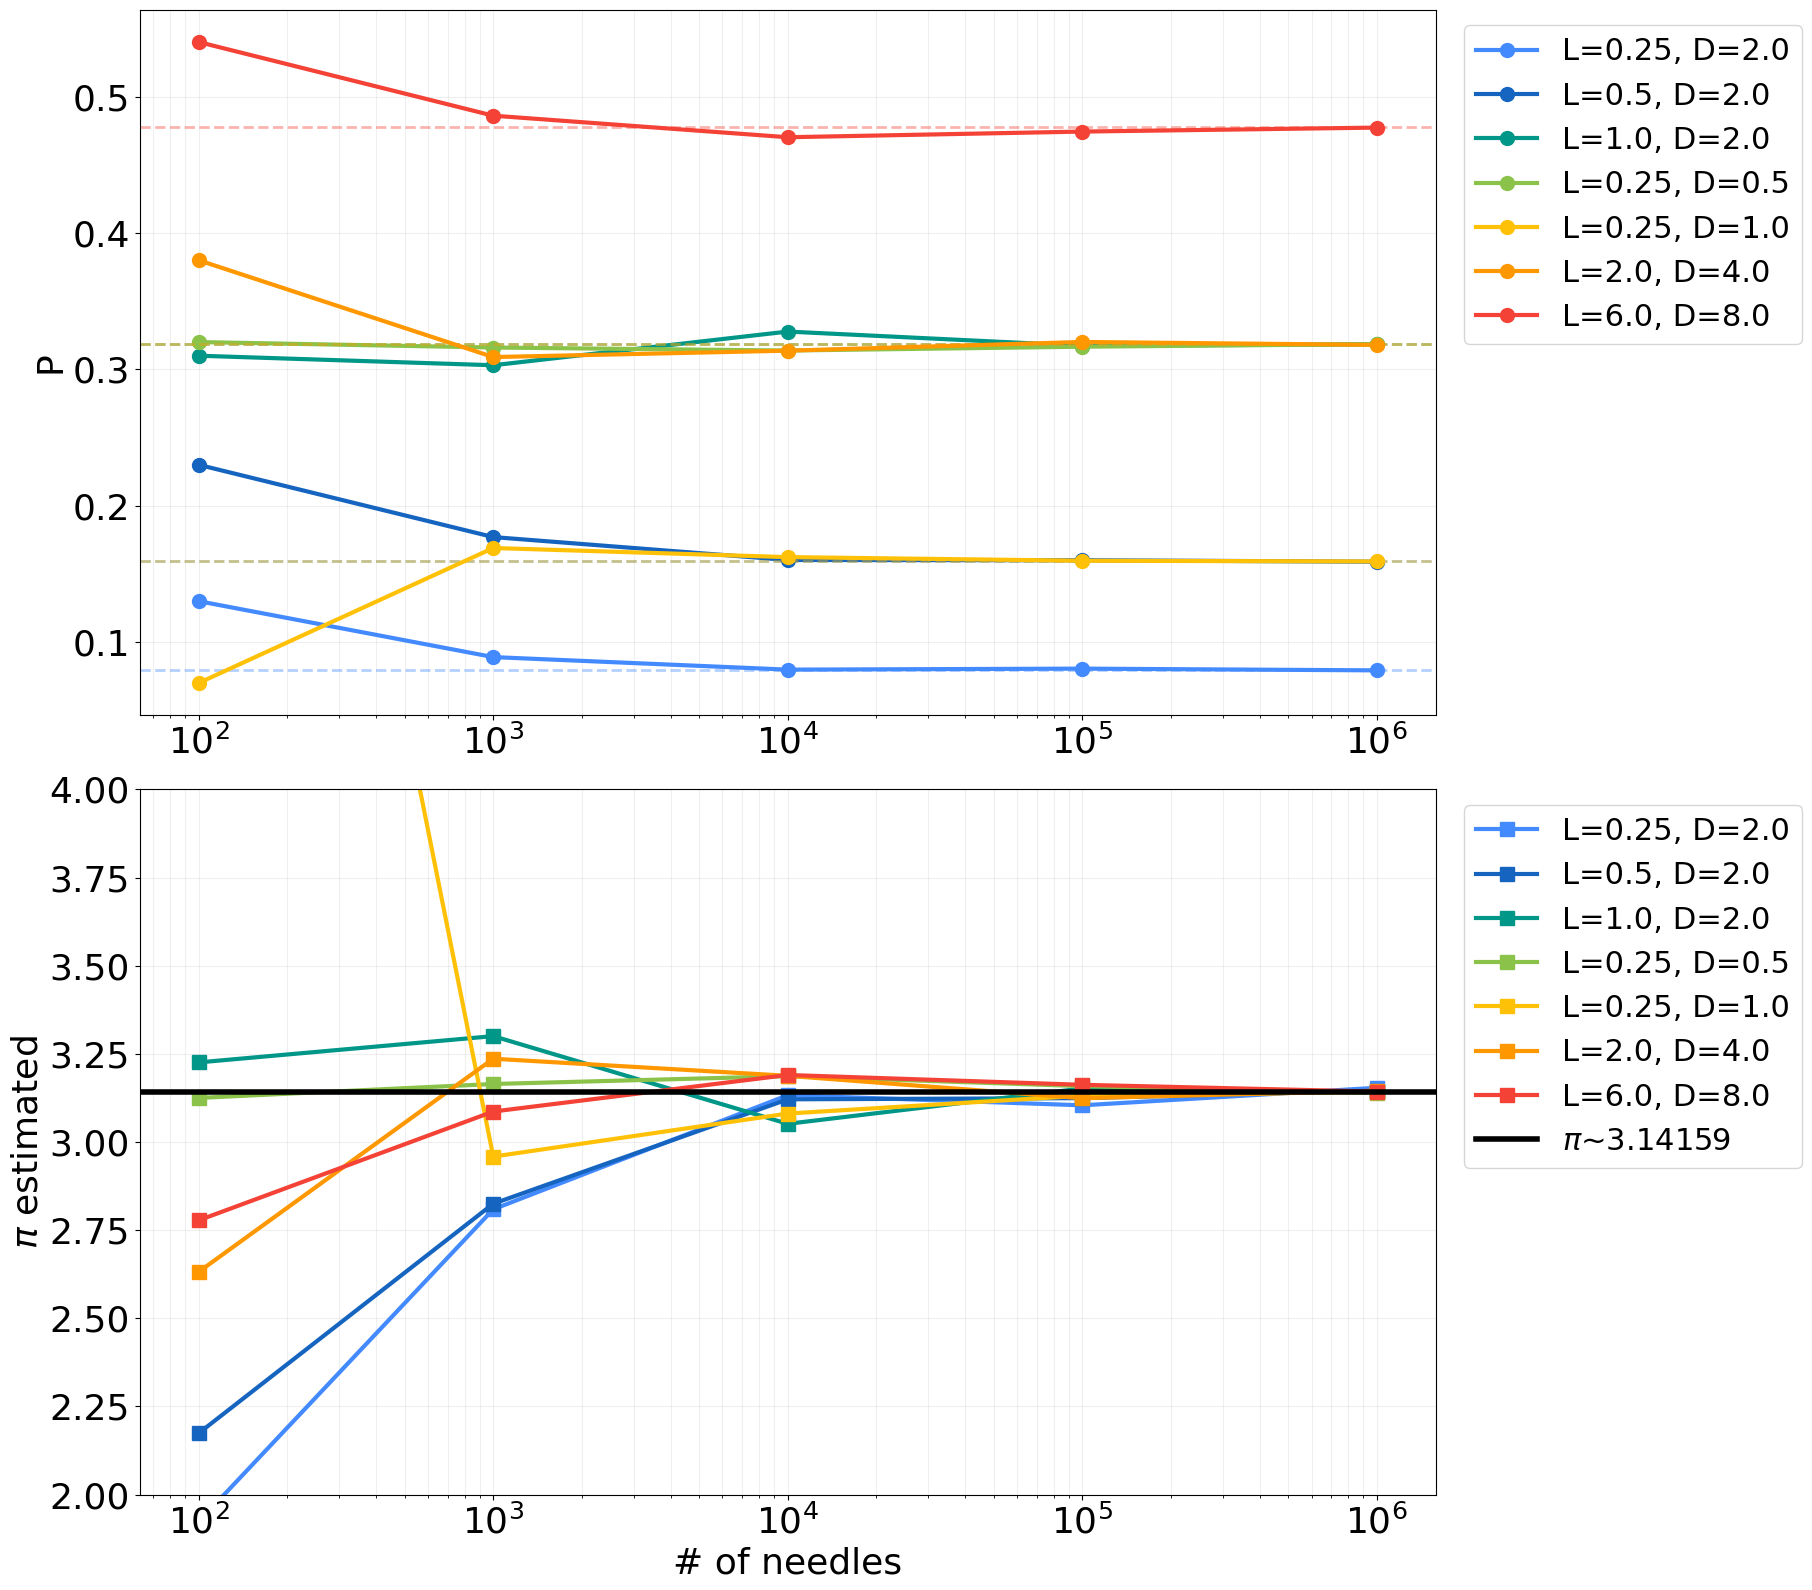


Convergence of Pi Estimates:
      N  Pi_L=0.25, D=2.0  Pi_L=0.5, D=2.0  Pi_L=1.0, D=2.0  Pi_L=0.25, D=0.5  Pi_L=0.25, D=1.0  Pi_L=2.0, D=4.0  Pi_L=6.0, D=8.0
    100          1.923077         2.173913         3.225806          3.125000          7.142857         2.631579         2.777778
   1000          2.808989         2.824859         3.300330          3.164557          2.958580         3.236246         3.086420
  10000          3.132832         3.121099         3.051572          3.186743          3.080715         3.187759         3.190132
 100000          3.104048         3.124414         3.151790          3.158560          3.131459         3.124219         3.162222
1000000          3.153818         3.145901         3.140911          3.139905          3.142046         3.145495         3.142908


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_buffon(L, D, num_needles):
    x = np.random.uniform(0, D/2, num_needles) # random center of mass (COM) 
    theta = np.random.uniform(0, np.pi/2, num_needles)  # random rotation angle 
    crossings = np.sum(x <= (L/2) * np.sin(theta))  # check if x <= (L/2) * sin(theta) 
    prob_est = crossings / num_needles
    pi_est = (2 * L) / (D * prob_est) if prob_est > 0 else 0  # pi estimation
    return prob_est, pi_est

cases = [(0.25, 2.0), (0.5, 2.0), (1.0, 2.0), (0.25, 0.5), 
         (0.25, 1.0), (2.0, 4.0), (6.0, 8.0)] # (L, D) pairs
iterations = [10**2, 10**3, 10**4, 10**5, 10**6] # of needles
results = {}

for L, D in cases:
    p_theoretical = (2 * L) / (D * np.pi)
    probs = []
    pi_estimated = []
    for n in iterations:
        est_p, est_pi = simulate_buffon(L, D, n)
        probs.append(est_p)
        pi_estimated.append(est_pi)
    results[f"L={L}, D={D}"] = (probs, p_theoretical, pi_estimated, L, D)

-fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 16)) 
colors = ['#448aff', '#1565c0', '#009688', '#8bc34a', '#ffc107', '#ff9800', '#f44336']

for i, (key, (probs, p_theoretical, pi_ests, L, D)) in enumerate(results.items()):
    # probability convergence
    ax1.plot(iterations, probs, marker='o', markersize=10, linewidth=3, 
             label=f"L={L}, D={D}", color=colors[i])
    ax1.axhline(y=p_theoretical, color=colors[i], linestyle='--', alpha=0.4, linewidth=2)
    # pi convergence
    ax2.plot(iterations, pi_ests, marker='s', markersize=10, linewidth=3, 
             label=f"L={L}, D={D}", color=colors[i])

ax1.set_xscale('log')
ax1.set_ylabel('P', fontsize=26)
ax1.tick_params(axis='both', which='major', labelsize=26) 
ax1.grid(True, which="both", ls="-", alpha=0.2)
ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=22)

ax2.set_xscale('log')
ax2.axhline(y=np.pi, color='black', linestyle='-', linewidth=4, label='$\pi$~3.14159')
ax2.set_ylabel('$\pi$ estimated', fontsize=26)
ax2.set_xlabel('# of needles', fontsize=26)
ax2.tick_params(axis='both', which='major', labelsize=26) 
ax2.set_ylim(2.0, 4.0) 
ax2.grid(True, which="both", ls="-", alpha=0.2)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=22)

save_path = "/Users/incisardag/Desktop/buffons_needle_part1.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

df_pi = {"N": iterations}
for label, (_, _, pi_ests, _, _) in results.items():
    df_pi[f"Pi_{label}"] = pi_ests

print("\nConvergence of Pi Estimates:")
print(pd.DataFrame(df_pi).to_string(index=False))